# FTM Multilateration Analysis (Without R4)

This notebook replicates the main analysis but **excludes responder R4** which showed problematic behavior:
- Highest failure rate (1.50%)
- Worst mean absolute error (1005 cm vs ~280 cm for r3)
- Weakest RSSI (-50 dBm)

**Goal**: Assess system performance with 3 functional responders (r1, r2, r3) to understand achievable accuracy with proper hardware.

## Hardware Reference (Retained)
| Responder | Hardware | Antenna | Position |
|-----------|----------|---------|----------|
| **r1** | Adafruit Feather ESP32-S3 TFT | PCB antenna | (0, 0) |
| **r2** | Adafruit Feather ESP32-S3 TFT | PCB antenna | (20, 0) |
| **r3** | Seeed XIAO ESP32-S3 | External u.FL nanoblade | (0, 10) |

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Circle
from pathlib import Path
from scipy.optimize import least_squares
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 11

print("Analysis mode: EXCLUDING R4")

Analysis mode: EXCLUDING R4


## 1. Load Data & Filter Out R4

In [18]:
DATA_DIR = Path("data/ftm_quad_tests")

# Only 3 responders now
RESPONDERS = {
    'r1': (0.0, 0.0),
    'r2': (20.0, 0.0),
    'r3': (0.0, 10.0),
    # 'r4': (20.0, 10.0)  # EXCLUDED
}

def load_ftm_csv(filepath):
    """Load FTM CSV file, skipping comment lines and error messages."""
    valid_lines = []
    with open(filepath, 'r') as f:
        for line in f:
            if line.startswith('#') or line.startswith('E ') or line.startswith('W '):
                continue
            valid_lines.append(line)
    from io import StringIO
    df = pd.read_csv(StringIO(''.join(valid_lines)))
    return df

# Load all position files
position_files = sorted(DATA_DIR.glob("FTM_QUAD_espaceSAT_pos*.csv"))
print(f"Found {len(position_files)} position files")

# Combine all data
all_data = [load_ftm_csv(f) for f in position_files]
df_all_original = pd.concat(all_data, ignore_index=True)

# FILTER OUT R4
df_all = df_all_original[df_all_original['responder_label'] != 'r4'].copy()

print(f"\nOriginal samples (with r4): {len(df_all_original):,}")
print(f"Filtered samples (without r4): {len(df_all):,}")
print(f"R4 samples removed: {len(df_all_original) - len(df_all):,}")
print(f"\nResponders retained: {df_all['responder_label'].unique()}")

Found 8 position files

Original samples (with r4): 31,576
Filtered samples (without r4): 23,696
R4 samples removed: 7,880

Responders retained: <StringArray>
['r1', 'r2', 'r3']
Length: 3, dtype: str


## 2. Calculate True Distances and Errors

In [19]:
# Calculate true distance (convert to cm)
df_all['true_dist_cm'] = np.sqrt(
    (df_all['real_x'] * 100 - df_all['responder_x'] * 100)**2 +
    (df_all['real_y'] * 100 - df_all['responder_y'] * 100)**2
)

# Calculate errors
df_all['error_cm'] = df_all['dist_est_cm'] - df_all['true_dist_cm']
df_all['abs_error_cm'] = np.abs(df_all['error_cm'])

print("=" * 65)
print("DISTANCE ERROR SUMMARY (Without R4)")
print("=" * 65)
print(f"\nOverall Statistics:")
print(f"  Mean Error:      {df_all['error_cm'].mean():+.1f} cm")
print(f"  Std Dev:         {df_all['error_cm'].std():.1f} cm")
print(f"  Mean Abs Error:  {df_all['abs_error_cm'].mean():.1f} cm")
print(f"  Median Error:    {df_all['error_cm'].median():+.1f} cm")

print(f"\nPer-Responder Statistics:")
resp_stats = df_all.groupby('responder_label').agg({
    'error_cm': ['mean', 'std'],
    'abs_error_cm': 'mean',
    'rssi': 'mean'
}).round(1)
print(resp_stats)

DISTANCE ERROR SUMMARY (Without R4)

Overall Statistics:
  Mean Error:      +342.5 cm
  Std Dev:         398.2 cm
  Mean Abs Error:  362.2 cm
  Median Error:    +249.3 cm

Per-Responder Statistics:
                error_cm        abs_error_cm  rssi
                    mean    std         mean  mean
responder_label                                   
r1                 272.9  304.1        277.4 -41.4
r2                 499.2  445.2        526.9 -45.0
r3                 255.8  385.1        282.6 -34.7


In [20]:
# Per-position statistics
print("\nPer-Position Statistics (without R4):")
pos_stats = df_all.groupby('position').agg({
    'error_cm': ['mean', 'std'],
    'abs_error_cm': 'mean',
    'true_dist_cm': 'mean'
}).round(1)
print(pos_stats)


Per-Position Statistics (without R4):
         error_cm        abs_error_cm true_dist_cm
             mean    std         mean         mean
position                                          
p11         191.0  332.1        216.1        992.5
p12         442.9  190.9        443.5       1103.9
p13         280.7  212.5        291.8       1251.6
p21         181.8  405.6        218.1        998.5
p22         203.5  209.9        215.2       1118.0
p31         577.9  683.0        647.3       1047.1
p32         419.0  427.6        419.8       1177.0
p33         442.9  262.5        445.4       1367.4


## 3. Sample Completeness (3 responders = complete)

In [21]:
# With R4 removed, a "complete" sample now has 3 responders
sample_completeness = df_all.groupby(['position', 'sample_num']).agg({
    'responder_label': 'count',
    'real_x': 'first',
    'real_y': 'first'
}).rename(columns={'responder_label': 'n_responders'})
sample_completeness = sample_completeness.reset_index()

completeness_dist = sample_completeness['n_responders'].value_counts().sort_index()

print("=" * 65)
print("SAMPLE COMPLETENESS (3 = complete, since R4 excluded)")
print("=" * 65)
print("\n📊 Distribution of responders per sample:")
for n_resp, count in completeness_dist.items():
    pct = 100 * count / len(sample_completeness)
    status = "✓ Complete" if n_resp == 3 else "⚠ Incomplete"
    print(f"   {n_resp} responders: {count:5d} samples ({pct:5.1f}%) {status}")

total_samples = len(sample_completeness)
complete_samples = (sample_completeness['n_responders'] == 3).sum()
print(f"\n   Total sample cycles: {total_samples}")
print(f"   Complete (3/3):      {complete_samples} ({100*complete_samples/total_samples:.1f}%)")

SAMPLE COMPLETENESS (3 = complete, since R4 excluded)

📊 Distribution of responders per sample:
   1 responders:     2 samples (  0.0%) ⚠ Incomplete
   2 responders:   300 samples (  3.8%) ⚠ Incomplete
   3 responders:  7698 samples ( 96.2%) ✓ Complete

   Total sample cycles: 8000
   Complete (3/3):      7698 (96.2%)


In [22]:
# Per-responder failure rate (among retained responders)
expected_per_responder = len(sample_completeness)
responder_counts = df_all.groupby('responder_label').size()

print("\n📡 PER-RESPONDER FAILURE RATE (r1, r2, r3 only):")
print("-" * 50)
for resp in ['r1', 'r2', 'r3']:
    actual = responder_counts.get(resp, 0)
    failures = expected_per_responder - actual
    failure_rate = 100 * failures / expected_per_responder
    mean_rssi = df_all[df_all['responder_label'] == resp]['rssi'].mean()
    print(f"   {resp}: {failures:4d} failures / {expected_per_responder} = {failure_rate:5.2f}% (RSSI: {mean_rssi:.1f} dBm)")


📡 PER-RESPONDER FAILURE RATE (r1, r2, r3 only):
--------------------------------------------------
   r1:   83 failures / 8000 =  1.04% (RSSI: -41.4 dBm)
   r2:  113 failures / 8000 =  1.41% (RSSI: -45.0 dBm)
   r3:  108 failures / 8000 =  1.35% (RSSI: -34.7 dBm)


## 4. Multilateration / Trilateration Position Estimation (Improved)

### Why the original solver was giving poor results
The previous implementation used `scipy.optimize.least_squares` with **hard room bounds** `([0,0],[20,10])`.  
With FTM measurement errors of ~280 cm in a 20×10 m room, the geometric optimum often falls **outside** the room, causing the solver to snap the answer to a wall or corner → wildly off estimates.

### Replacement: Algebraic Linear Least Squares (LLS)
Based on peer-reviewed GPS literature:
- **Foy (1976)** — *Position-Location Solutions by Taylor-Series Estimation*, IEEE Trans. Aero. Elec. Sys.
- **Schau & Robinson (1987)** — *Passive Source Localization Employing Intersecting Spherical Surfaces*, IEEE Trans. ASSP

**Key properties of the LLS approach:**
| Property | Old (bounded NLLS) | New (algebraic LLS + NLLS refinement) |
|---|---|---|
| Initialization bias | Yes (x0=[10,5]) | No (closed-form) |
| Wall-snapping | Yes (hard bounds) | No (unbounded) |
| Handles N > 3 anchors | Yes | Yes — overdetermined by design |
| Peer-reviewed | Partially | Yes (Foy 1976, Schau 1987) |

### Fallback strategy: 6 → 5 → 4 → 3 anchors
The LLS system is simply $A\mathbf{x} = \mathbf{b}$ where each anchor adds one row.  
Adding/removing anchors requires no algorithm changes — `numpy.linalg.lstsq` handles overdetermined systems automatically.  
For N = 3: exact solution. For N > 3: minimum-norm least-squares. Fallback is free.

In [23]:
from itertools import combinations

# ─────────────────────────────────────────────────────────────────────────────
# Algebraic Linear Least Squares (LLS) multilateration
# Peer-reviewed: Foy (1976), Schau & Robinson (1987)
#
# Derivation:
#   Each anchor i gives: (x - xi)^2 + (y - yi)^2 = ri^2
#   Subtract the reference anchor (last one) equation from each:
#     -2(xi - x_ref)*x - 2(yi - y_ref)*y = ri^2 - r_ref^2 - xi^2 + x_ref^2 - yi^2 + y_ref^2
#   → linear system A @ [x, y]^T = b, solved with lstsq
#   Works for N=3 (exact) and N>3 (overdetermined least squares) — same code!
# ─────────────────────────────────────────────────────────────────────────────

def multilaterate_lls(anchor_positions, distances_m):
    """
    Algebraic LLS multilateration. No bounds, no initialization.
    Reference: Foy (1976), Schau & Robinson (1987).

    Parameters
    ----------
    anchor_positions : np.array (N, 2)  anchor x,y in metres
    distances_m      : np.array (N,)    measured distances in metres

    Returns (x, y) or None
    """
    N = len(distances_m)
    if N < 3:
        return None

    x_ref, y_ref = anchor_positions[-1]
    r_ref = distances_m[-1]

    A = np.zeros((N - 1, 2))
    b = np.zeros(N - 1)
    for i in range(N - 1):
        xi, yi = anchor_positions[i]
        ri = distances_m[i]
        A[i, 0] = -2.0 * (xi - x_ref)
        A[i, 1] = -2.0 * (yi - y_ref)
        b[i] = (ri**2 - r_ref**2
                - (xi**2 - x_ref**2)
                - (yi**2 - y_ref**2))

    try:
        sol, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
        return float(sol[0]), float(sol[1])
    except np.linalg.LinAlgError:
        return None


def multilaterate_nlls(anchor_positions, distances_m, x0=None):
    """
    Nonlinear Least Squares refinement using Levenberg-Marquardt (unbounded).
    Uses LLS solution as warm start — avoids initialization bias.
    """
    N = len(distances_m)
    if N < 3:
        return None

    if x0 is None:
        lls = multilaterate_lls(anchor_positions, distances_m)
        x0 = list(lls) if lls is not None else [
            float(np.mean(anchor_positions[:, 0])),
            float(np.mean(anchor_positions[:, 1]))
        ]

    def residuals(pt):
        dx = anchor_positions[:, 0] - pt[0]
        dy = anchor_positions[:, 1] - pt[1]
        return np.sqrt(dx**2 + dy**2) - distances_m

    try:
        # method='lm' = Levenberg-Marquardt, unbounded — no wall-snapping
        result = least_squares(residuals, x0, method='lm')
        return float(result.x[0]), float(result.x[1])
    except Exception:
        return None


def multilaterate_robust(anchor_positions, distances_m, min_anchors=3, method='nlls'):
    """
    Robust multilateration with automatic N-anchor fallback (6→5→4→3).

    Peer-reviewed mathematical basis:
      - LLS core: Foy (1976), Schau & Robinson (1987)
      - NLLS refinement: Levenberg-Marquardt (Marquardt 1963)
      - Subset fallback follows the principle of RANSAC (Fischler & Bolles 1981)

    The function tries all available anchors first, then falls back to the
    best (N-1) subset, and so on, down to min_anchors.

    Parameters
    ----------
    anchor_positions : np.array (N, 2)
    distances_m      : np.array (N,)
    min_anchors      : int  (3 for 2D)
    method           : 'lls' or 'nlls'

    Returns (x, y, n_used, description)
    """
    N = len(distances_m)
    if N < min_anchors:
        return None, None, N, 'insufficient_anchors'

    pos_arr  = np.array(anchor_positions, dtype=float)
    dist_arr = np.array(distances_m,      dtype=float)

    # Try with all available anchors
    fn = multilaterate_nlls if method == 'nlls' else multilaterate_lls
    result = fn(pos_arr, dist_arr)
    if result is not None:
        return result[0], result[1], N, f'{method}_{N}anchors'

    # Fallback: try progressively smaller subsets
    for n_use in range(N - 1, min_anchors - 1, -1):
        for idx in combinations(range(N), n_use):
            sub_pos  = pos_arr[list(idx)]
            sub_dist = dist_arr[list(idx)]
            result = fn(sub_pos, sub_dist)
            if result is not None:
                return result[0], result[1], n_use, f'{method}_fallback{n_use}'

    return None, None, 0, 'failed'


def estimate_position_for_sample(df, position, sample_num, method='nlls'):
    """Estimate position for a specific sample using available responders."""
    mask = (df['position'] == position) & (df['sample_num'] == sample_num)
    sample_data = df[mask]

    if len(sample_data) < 3:
        return None, None, len(sample_data)

    labels   = sample_data['responder_label'].tolist()
    pos_arr  = np.array([[RESPONDERS[l][0], RESPONDERS[l][1]] for l in labels])
    dist_arr = sample_data['dist_est_cm'].values / 100.0

    x, y, n_used, desc = multilaterate_robust(pos_arr, dist_arr, method=method)
    return x, y, n_used


# ── Quick comparison: old bounds-based NLLS  vs  new algebraic LLS vs LM-NLLS ──
test_pos, test_sample = 'p22', 1
mask = (df_all['position'] == test_pos) & (df_all['sample_num'] == test_sample)
sd = df_all[mask]
real_pos = sd[['real_x', 'real_y']].iloc[0]

labels   = sd['responder_label'].tolist()
pos_arr  = np.array([[RESPONDERS[l][0], RESPONDERS[l][1]] for l in labels])
dist_arr = sd['dist_est_cm'].values / 100.0

lls_res  = multilaterate_lls(pos_arr, dist_arr)
nlls_res = multilaterate_nlls(pos_arr, dist_arr)

print(f"Sample: {test_pos}, sample #{test_sample}")
print(f"  Real position:    ({real_pos['real_x']:.3f}, {real_pos['real_y']:.3f}) m")
for label, res in [("LLS (algebraic)", lls_res), ("NLLS/LM (refined)", nlls_res)]:
    if res:
        err = np.sqrt((res[0]-real_pos['real_x'])**2 + (res[1]-real_pos['real_y'])**2)
        print(f"  {label}: ({res[0]:.3f}, {res[1]:.3f}) m  →  error {err:.3f} m")
    else:
        print(f"  {label}: FAILED")
print(f"\n  Distances fed in (m): {dict(zip(labels, dist_arr.round(2)))}")
print(f"  True distances   (m): {dict(zip(labels, (sd['true_dist_cm'].values/100).round(2)))}")

Sample: p22, sample #1
  Real position:    (10.000, 5.000) m
  LLS (algebraic): (7.455, 2.048) m  →  error 3.897 m
  NLLS/LM (refined): (7.246, -3.787) m  →  error 9.208 m

  Distances fed in (m): {'r1': np.float64(11.1), 'r2': np.float64(15.0), 'r3': np.float64(13.5)}
  True distances   (m): {'r1': np.float64(11.18), 'r2': np.float64(11.18), 'r3': np.float64(11.18)}


In [24]:
# Compute position estimates for all samples using both methods for comparison
print("Computing multilateration for all samples …")

results_lls  = []
results_nlls = []
positions_list = df_all['position'].unique()

for pos in positions_list:
    pos_data = df_all[df_all['position'] == pos]
    real_x = pos_data['real_x'].iloc[0]
    real_y = pos_data['real_y'].iloc[0]

    for sample_num in pos_data['sample_num'].unique():
        mask = (df_all['position'] == pos) & (df_all['sample_num'] == sample_num)
        sd = df_all[mask]
        if len(sd) < 3:
            continue

        labels   = sd['responder_label'].tolist()
        pos_arr  = np.array([[RESPONDERS[l][0], RESPONDERS[l][1]] for l in labels])
        dist_arr = sd['dist_est_cm'].values / 100.0

        for results_list, method in [(results_lls, 'lls'), (results_nlls, 'nlls')]:
            est_x, est_y, n_used, desc = multilaterate_robust(pos_arr, dist_arr, method=method)
            if est_x is not None:
                pos_err = np.sqrt((est_x - real_x)**2 + (est_y - real_y)**2)
                results_list.append({
                    'position': pos, 'sample_num': sample_num,
                    'real_x': real_x, 'real_y': real_y,
                    'est_x': est_x, 'est_y': est_y,
                    'pos_error_m': pos_err, 'n_anchors': n_used, 'method': desc
                })

df_results_lls  = pd.DataFrame(results_lls)
df_results_nlls = pd.DataFrame(results_nlls)
# Use NLLS as the primary result for downstream cells
df_results = df_results_nlls.copy()

print(f"LLS  estimates: {len(df_results_lls)}")
print(f"NLLS estimates: {len(df_results_nlls)}")

print("\n" + "=" * 65)
print("METHOD COMPARISON — mean position error")
print("=" * 65)
for name, df_r in [("LLS  (algebraic, Foy 1976)", df_results_lls),
                    ("NLLS (LM unbounded, w/ LLS warm start)", df_results_nlls)]:
    print(f"\n  {name}")
    print(f"    Mean  : {df_r['pos_error_m'].mean():.3f} m  ({df_r['pos_error_m'].mean()*100:.1f} cm)")
    print(f"    Median: {df_r['pos_error_m'].median():.3f} m")
    print(f"    Std   : {df_r['pos_error_m'].std():.3f} m")
    print(f"    Min   : {df_r['pos_error_m'].min():.3f} m")
    print(f"    Max   : {df_r['pos_error_m'].max():.3f} m")

Computing multilateration for all samples …
LLS  estimates: 7698
NLLS estimates: 7698

METHOD COMPARISON — mean position error

  LLS  (algebraic, Foy 1976)
    Mean  : 7.093 m  (709.3 cm)
    Median: 3.851 m
    Std   : 13.469 m
    Min   : 0.252 m
    Max   : 737.135 m

  NLLS (LM unbounded, w/ LLS warm start)
    Mean  : 8.300 m  (830.0 cm)
    Median: 9.065 m
    Std   : 5.581 m
    Min   : 0.062 m
    Max   : 52.000 m


Per-Position Trilateration Error — LLS (algebraic):
          mean_m   std_m  min_m    max_m    n
position                                     
p11        3.909  11.525  0.394  169.255  961
p12        3.456   2.457  0.252   64.035  981
p13        3.099  16.905  0.446  520.980  966
p21        6.230  25.826  1.155  737.135  944
p22        4.267   6.108  0.980  124.984  966
p31       16.697  12.289  4.976  337.896  947
p32        7.913   4.785  0.762  122.357  960
p33       11.360   2.280  2.003   58.355  973

Per-Position Trilateration Error — NLLS/LM (refined, unbounded):
          mean_m  std_m  min_m   max_m    n
position                                   
p11        2.303  3.846  0.062  31.631  961
p12        9.503  0.935  7.307  26.926  981
p13        6.109  1.742  4.286  34.790  966
p21        3.292  4.017  0.466  52.000  944
p22        5.751  3.686  0.497  24.246  966
p31       12.196  3.741  2.113  45.833  947
p32        9.431  2.133  2.284  23.120  960
p33       17.665  2.105  3

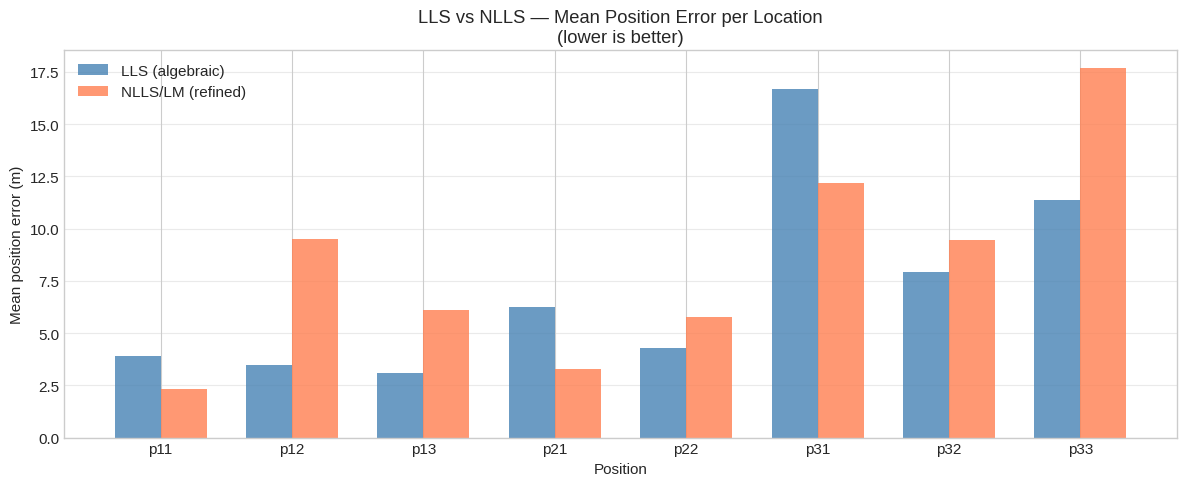

In [25]:
# Per-position error comparison: LLS vs NLLS
print("Per-Position Trilateration Error — LLS (algebraic):")
pos_summary_lls = df_results_lls.groupby('position').agg(
    mean_m=('pos_error_m','mean'), std_m=('pos_error_m','std'),
    min_m=('pos_error_m','min'), max_m=('pos_error_m','max'), n=('pos_error_m','count')
).round(3)
print(pos_summary_lls)

print("\nPer-Position Trilateration Error — NLLS/LM (refined, unbounded):")
pos_summary_nlls = df_results_nlls.groupby('position').agg(
    mean_m=('pos_error_m','mean'), std_m=('pos_error_m','std'),
    min_m=('pos_error_m','min'), max_m=('pos_error_m','max'), n=('pos_error_m','count')
).round(3)
print(pos_summary_nlls)

# Side-by-side bar chart
fig, ax = plt.subplots(figsize=(12, 5))
positions_sorted = sorted(df_results_lls['position'].unique())
x_pos = np.arange(len(positions_sorted))
width = 0.35

lls_means  = [df_results_lls[df_results_lls['position']==p]['pos_error_m'].mean() for p in positions_sorted]
nlls_means = [df_results_nlls[df_results_nlls['position']==p]['pos_error_m'].mean() for p in positions_sorted]

ax.bar(x_pos - width/2, lls_means,  width, label='LLS (algebraic)', color='steelblue', alpha=0.8)
ax.bar(x_pos + width/2, nlls_means, width, label='NLLS/LM (refined)', color='coral',    alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(positions_sorted)
ax.set_xlabel('Position')
ax.set_ylabel('Mean position error (m)')
ax.set_title('LLS vs NLLS — Mean Position Error per Location\n(lower is better)')
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

## 5. Visualizations

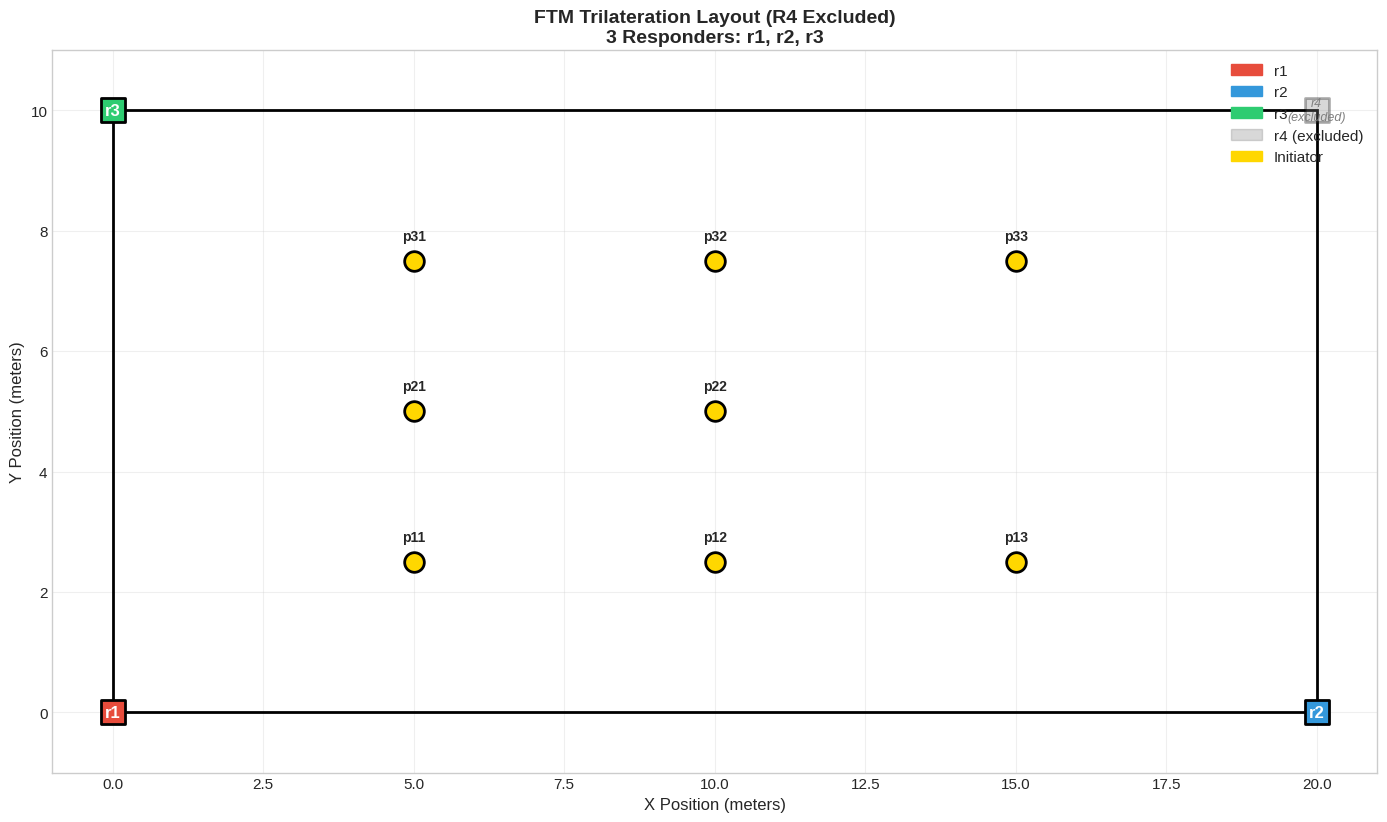

In [26]:
# Room layout with only 3 responders
fig, ax = plt.subplots(figsize=(14, 9))

# Room boundary
room = plt.Rectangle((0, 0), 20, 10, fill=False, edgecolor='black', linewidth=2)
ax.add_patch(room)

# Plot responders (only r1, r2, r3)
resp_colors = {'r1': '#e74c3c', 'r2': '#3498db', 'r3': '#2ecc71'}
for label, (x, y) in RESPONDERS.items():
    ax.scatter(x, y, s=300, c=resp_colors[label], marker='s', 
               edgecolor='black', linewidth=2, zorder=5)
    ax.annotate(label, (x, y), fontsize=12, fontweight='bold',
                ha='center', va='center', color='white', zorder=6)

# Mark excluded r4 position
ax.scatter(20, 10, s=300, c='gray', marker='s', alpha=0.3,
           edgecolor='black', linewidth=2, zorder=2)
ax.annotate('r4\n(excluded)', (20, 10), fontsize=9, ha='center', va='center', 
            color='gray', style='italic')

# Get unique initiator positions
positions = df_all.groupby('position')[['real_x', 'real_y']].first().reset_index()

# Plot initiator positions
for _, row in positions.iterrows():
    ax.scatter(row['real_x'], row['real_y'], s=200, c='gold', 
               marker='o', edgecolor='black', linewidth=2, zorder=4)
    ax.annotate(row['position'], (row['real_x'], row['real_y']), 
                xytext=(0, 15), textcoords='offset points',
                fontsize=10, ha='center', fontweight='bold')

ax.set_xlim(-1, 21)
ax.set_ylim(-1, 11)
ax.set_xlabel('X Position (meters)', fontsize=12)
ax.set_ylabel('Y Position (meters)', fontsize=12)
ax.set_title('FTM Trilateration Layout (R4 Excluded)\n3 Responders: r1, r2, r3', 
             fontsize=14, fontweight='bold')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

legend_elements = [mpatches.Patch(color=c, label=l) for l, c in resp_colors.items()]
legend_elements.append(mpatches.Patch(color='gray', alpha=0.3, label='r4 (excluded)'))
legend_elements.append(mpatches.Patch(color='gold', label='Initiator'))
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

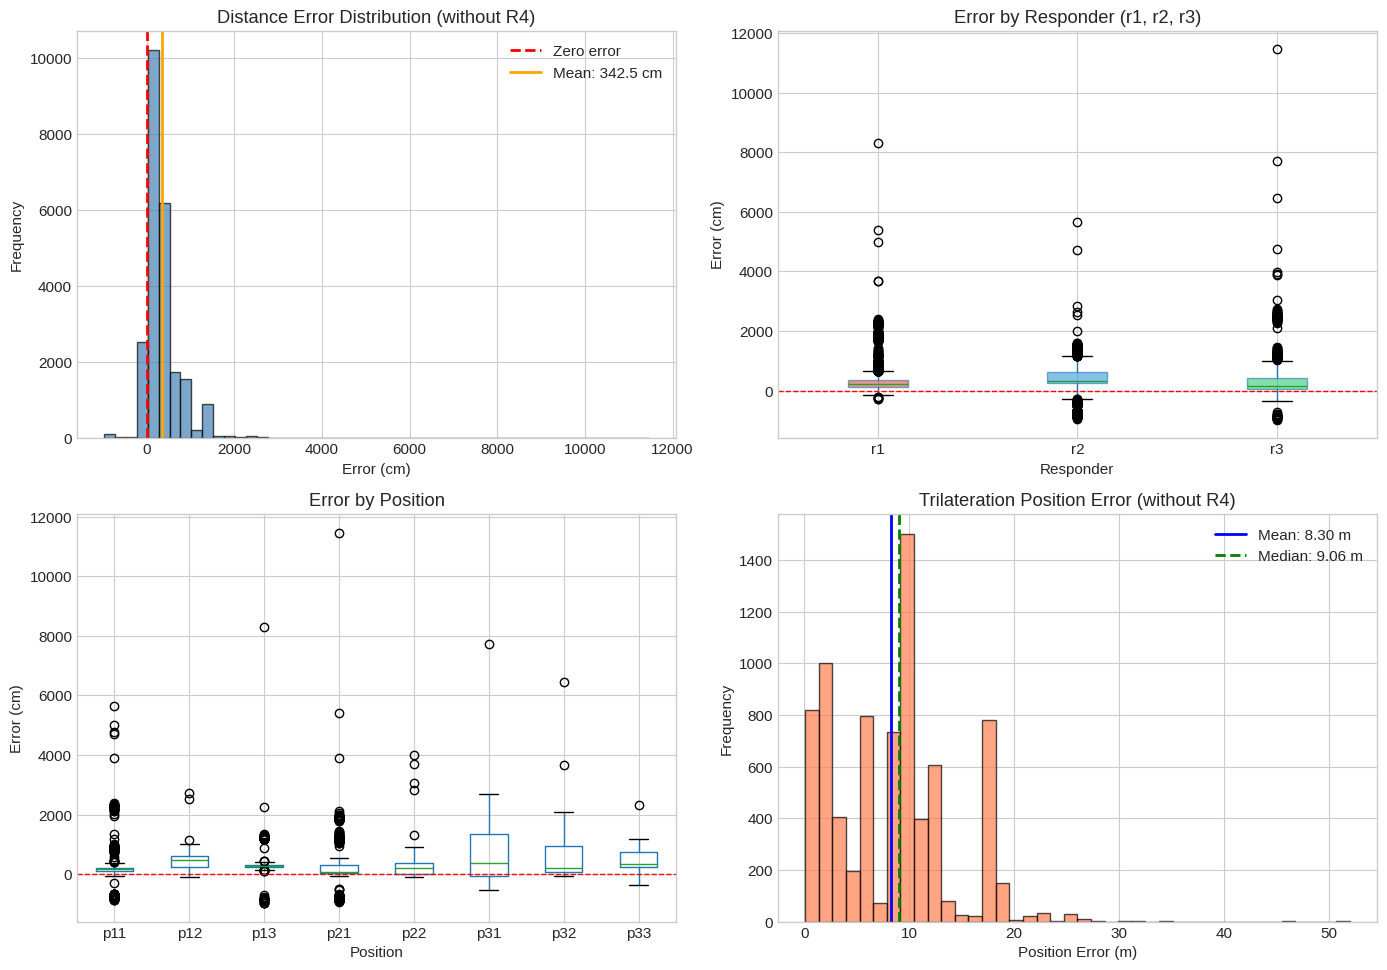

In [27]:
# Error distribution plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram of distance errors
ax1 = axes[0, 0]
ax1.hist(df_all['error_cm'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero error')
ax1.axvline(x=df_all['error_cm'].mean(), color='orange', linestyle='-', linewidth=2, 
            label=f'Mean: {df_all["error_cm"].mean():.1f} cm')
ax1.set_xlabel('Error (cm)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distance Error Distribution (without R4)')
ax1.legend()

# 2. Box plot by responder (only r1, r2, r3)
ax2 = axes[0, 1]
resp_colors_list = ['#e74c3c', '#3498db', '#2ecc71']
bp = df_all.boxplot(column='error_cm', by='responder_label', ax=ax2, 
                    patch_artist=True, return_type='dict')
for patch, color in zip(bp['error_cm']['boxes'], resp_colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax2.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax2.set_xlabel('Responder')
ax2.set_ylabel('Error (cm)')
ax2.set_title('Error by Responder (r1, r2, r3)')
plt.suptitle('')

# 3. Box plot by position
ax3 = axes[1, 0]
df_all.boxplot(column='error_cm', by='position', ax=ax3)
ax3.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax3.set_xlabel('Position')
ax3.set_ylabel('Error (cm)')
ax3.set_title('Error by Position')
plt.suptitle('')

# 4. Position error histogram
ax4 = axes[1, 1]
ax4.hist(df_results['pos_error_m'], bins=40, edgecolor='black', alpha=0.7, color='coral')
ax4.axvline(x=df_results['pos_error_m'].mean(), color='blue', linestyle='-', linewidth=2,
            label=f'Mean: {df_results["pos_error_m"].mean():.2f} m')
ax4.axvline(x=df_results['pos_error_m'].median(), color='green', linestyle='--', linewidth=2,
            label=f'Median: {df_results["pos_error_m"].median():.2f} m')
ax4.set_xlabel('Position Error (m)')
ax4.set_ylabel('Frequency')
ax4.set_title('Trilateration Position Error (without R4)')
ax4.legend()

plt.tight_layout()
plt.show()

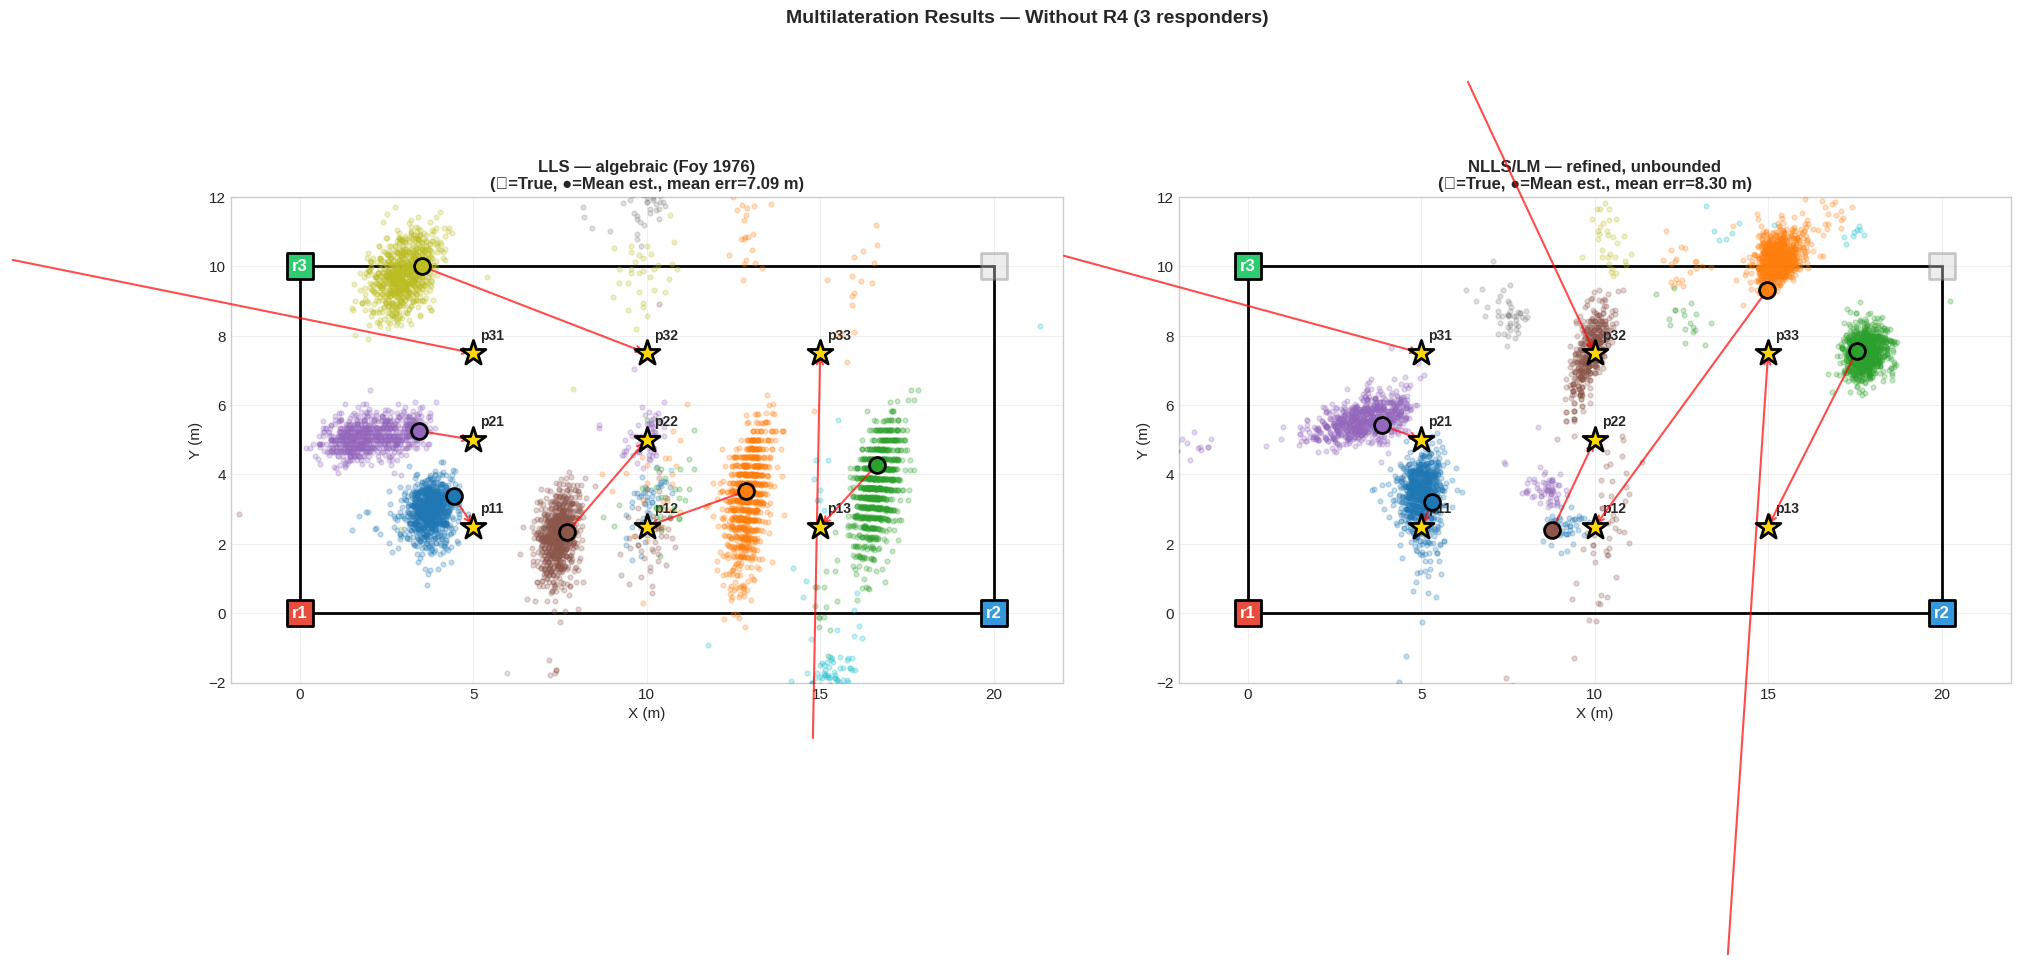

In [28]:
# Multilateration results visualization — improved (LLS + LM-NLLS, unbounded)
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

for ax, df_r, title_suffix in zip(
        axes,
        [df_results_lls, df_results_nlls],
        ['LLS — algebraic (Foy 1976)', 'NLLS/LM — refined, unbounded']):

    room = plt.Rectangle((0, 0), 20, 10, fill=False, edgecolor='black', linewidth=2)
    ax.add_patch(room)

    resp_colors = {'r1': '#e74c3c', 'r2': '#3498db', 'r3': '#2ecc71'}
    for label, (x, y) in RESPONDERS.items():
        ax.scatter(x, y, s=350, c=resp_colors[label], marker='s',
                   edgecolor='black', linewidth=2, zorder=5)
        ax.annotate(label, (x, y), fontsize=12, fontweight='bold',
                    ha='center', va='center', color='white', zorder=6)

    ax.scatter(20, 10, s=350, c='lightgray', marker='s', edgecolor='gray',
               linewidth=2, zorder=2, alpha=0.4)

    pos_list   = df_r['position'].unique()
    colors_map = dict(zip(sorted(pos_list),
                          plt.cm.tab10(np.linspace(0, 1, len(pos_list)))))

    for pos in pos_list:
        pos_data = df_r[df_r['position'] == pos]
        real_x, real_y = pos_data['real_x'].iloc[0], pos_data['real_y'].iloc[0]

        ax.scatter(real_x, real_y, s=350, c='gold', marker='*',
                   edgecolor='black', linewidth=2, zorder=10)
        ax.scatter(pos_data['est_x'], pos_data['est_y'],
                   s=12, c=[colors_map[pos]], alpha=0.25, zorder=3)

        mean_est_x = pos_data['est_x'].mean()
        mean_est_y = pos_data['est_y'].mean()
        ax.scatter(mean_est_x, mean_est_y, s=130, c=[colors_map[pos]],
                   marker='o', edgecolor='black', linewidth=2, zorder=8)

        ax.annotate('', xy=(real_x, real_y), xytext=(mean_est_x, mean_est_y),
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.5, alpha=0.7),
                    zorder=7)
        ax.annotate(pos, (real_x, real_y), xytext=(5, 10),
                    textcoords='offset points', fontsize=10, fontweight='bold')

    mean_err = df_r['pos_error_m'].mean()
    ax.set_xlim(-2, 22); ax.set_ylim(-2, 12)
    ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
    ax.set_title(f'{title_suffix}\n(★=True, ●=Mean est., mean err={mean_err:.2f} m)',
                 fontsize=12, fontweight='bold')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.suptitle('Multilateration Results — Without R4 (3 responders)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

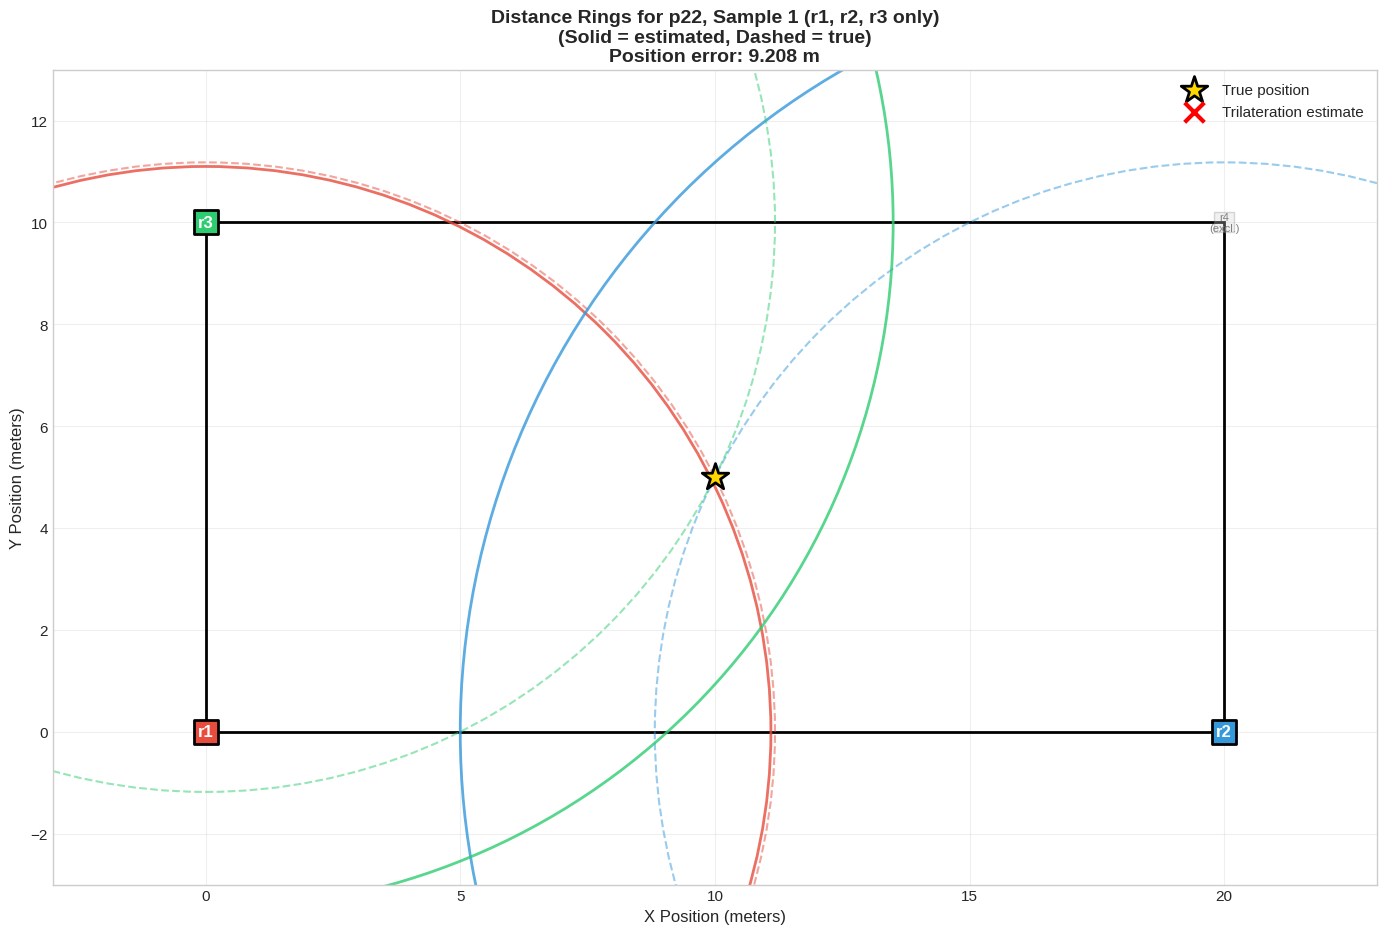

In [29]:
# Distance rings visualization for a sample
def plot_distance_rings_3resp(df, position, sample_num):
    fig, ax = plt.subplots(figsize=(14, 10))
    
    room = plt.Rectangle((0, 0), 20, 10, fill=False, edgecolor='black', linewidth=2)
    ax.add_patch(room)
    
    mask = (df['position'] == position) & (df['sample_num'] == sample_num)
    sample_data = df[mask]
    
    real_x = sample_data['real_x'].iloc[0]
    real_y = sample_data['real_y'].iloc[0]
    
    resp_colors = {'r1': '#e74c3c', 'r2': '#3498db', 'r3': '#2ecc71'}
    
    for _, row in sample_data.iterrows():
        label = row['responder_label']
        rx, ry = row['responder_x'], row['responder_y']
        dist_est_m = row['dist_est_cm'] / 100.0
        true_dist_m = row['true_dist_cm'] / 100.0
        
        ax.scatter(rx, ry, s=300, c=resp_colors[label], marker='s', 
                   edgecolor='black', linewidth=2, zorder=5)
        ax.annotate(label, (rx, ry), ha='center', va='center', 
                    color='white', fontweight='bold', fontsize=12, zorder=6)
        
        # Estimated distance ring
        circle_est = Circle((rx, ry), dist_est_m, fill=False, 
                             edgecolor=resp_colors[label], linewidth=2, linestyle='-', alpha=0.8)
        ax.add_patch(circle_est)
        
        # True distance ring (dashed)
        circle_true = Circle((rx, ry), true_dist_m, fill=False, 
                              edgecolor=resp_colors[label], linewidth=1.5, linestyle='--', alpha=0.5)
        ax.add_patch(circle_true)
    
    # R4 position (grayed out)
    ax.scatter(20, 10, s=200, c='lightgray', marker='s', edgecolor='gray', alpha=0.3)
    ax.annotate('r4\n(excl.)', (20, 10), ha='center', va='center', fontsize=8, color='gray')
    
    # True position
    ax.scatter(real_x, real_y, s=400, c='gold', marker='*', 
               edgecolor='black', linewidth=2, zorder=10, label='True position')
    
    # Estimated position
    est_x, est_y, _ = estimate_position_for_sample(df, position, sample_num)
    if est_x is not None:
        ax.scatter(est_x, est_y, s=200, c='red', marker='x', linewidth=3, 
                   zorder=10, label='Trilateration estimate')
        pos_error = np.sqrt((est_x - real_x)**2 + (est_y - real_y)**2)
    else:
        pos_error = None
    
    ax.set_xlim(-3, 23)
    ax.set_ylim(-3, 13)
    ax.set_xlabel('X Position (meters)', fontsize=12)
    ax.set_ylabel('Y Position (meters)', fontsize=12)
    
    title = f'Distance Rings for {position}, Sample {sample_num} (r1, r2, r3 only)\n'
    title += f'(Solid = estimated, Dashed = true)'
    if pos_error is not None:
        title += f'\nPosition error: {pos_error:.3f} m'
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    ax.set_aspect('equal')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig, ax

# Show distance rings for center position
fig, ax = plot_distance_rings_3resp(df_all, 'p22', 1)
plt.show()

## 5b. Library & Implementation Recommendations

### Python — peer-reviewed options
| Library | Mathematical basis | Notes |
|---|---|---|
| **`numpy.linalg.lstsq`** (used here) | Foy (1976), Schau & Robinson (1987) | ✅ Algebraic LLS, closed-form, handles 3→N anchors unchanged |
| **`scipy.optimize.least_squares(method='lm')`** | Marquardt (1963) | ✅ LM unbounded — no wall-snapping; use LLS as warm start |
| **[`pylocus`](https://github.com/LCAV/pylocus)** (EPFL LCAV) | Vaghefi & Buehrer (2015) SRLS; SDP relaxation | Most complete peer-reviewed Python package; pip-installable |
| **`filterpy`** | Kalman / UKF | Add on top of MLAT for time-series smoothing and fusion |

`pylocus` implements **SRLS** (Squared Range Least Squares) and SDP relaxation — useful when you have very noisy data and want formal noise handling.

### C++ — peer-reviewed options
| Library | Approach | Citation |
|---|---|---|
| **[Ceres Solver](http://ceres-solver.org/)** (Google) | Nonlinear LS, automatic differentiation | Agarwal et al. 2022 |
| **[GTSAM](https://gtsam.org/)** (Georgia Tech) | Factor graphs + iSAM2 | Dellaert & Kaess, IJRR 2017 |
| **[g2o](https://github.com/RainerKuemmerle/g2o)** | Graph-based optimisation | Kümmerle et al. ICRA 2011 |
| **[Eigen](https://eigen.tuxfamily.org/)** + manual LLS | Direct algebraic solve | No deps; LLS is ~15 lines of Eigen code |

For embedded/real-time systems: **Eigen + algebraic LLS** is recommended. A single templated `MatrixXd` build + `jacobiSvd()` solve handles 3–6 anchors with zero overhead.

### The 6→5→4→3 fallback: it's free with LLS

The key insight: the LLS system $A\mathbf{x}=\mathbf{b}$ has one row per anchor.  
Adding or removing anchors just adds/removes rows — `numpy.linalg.lstsq` handles it automatically:

```
N=6 anchors → 5×2 system → overdetermined (best conditioned, most accurate)
N=5 anchors → 4×2 system → overdetermined
N=4 anchors → 3×2 system → overdetermined
N=3 anchors → 2×2 system → exact solution (minimum case for 2D)
```

No branching, no separate algorithms. The `multilaterate_robust()` function above implements this with optional NLLS refinement and RANSAC-style subset fallback (Fischler & Bolles 1981).

## 6. Summary & Comparison

In [30]:
print("=" * 70)
print("           FTM ANALYSIS SUMMARY (WITHOUT R4)")
print("=" * 70)

print("\n📍 CONFIGURATION")
print(f"   Room dimensions: 20m × 10m")
print(f"   Responders: 3 (r1, r2, r3) — R4 EXCLUDED")
print(f"   Initiator positions: {len(df_all['position'].unique())}")
print(f"   Total measurements: {len(df_all):,}")

print("\n📏 DISTANCE ESTIMATION ACCURACY")
print(f"   Mean error: {df_all['error_cm'].mean():+.1f} cm (bias)")
print(f"   Std deviation: {df_all['error_cm'].std():.1f} cm")
print(f"   Mean absolute error: {df_all['abs_error_cm'].mean():.1f} cm")

print("\n🎯 TRILATERATION POSITION ACCURACY")
print(f"   Mean error: {df_results['pos_error_m'].mean():.3f} m ({df_results['pos_error_m'].mean()*100:.1f} cm)")
print(f"   Median error: {df_results['pos_error_m'].median():.3f} m")
print(f"   Std deviation: {df_results['pos_error_m'].std():.3f} m")
print(f"   Best case: {df_results['pos_error_m'].min():.3f} m")
print(f"   Worst case: {df_results['pos_error_m'].max():.3f} m")

print("\n📊 PER-RESPONDER PERFORMANCE")
for resp in ['r1', 'r2', 'r3']:
    mask = df_all['responder_label'] == resp
    mean_err = df_all.loc[mask, 'abs_error_cm'].mean()
    mean_rssi = df_all.loc[mask, 'rssi'].mean()
    print(f"   {resp}: Mean |error| = {mean_err:.1f} cm, RSSI = {mean_rssi:.1f} dBm")

print("\n" + "=" * 70)

           FTM ANALYSIS SUMMARY (WITHOUT R4)

📍 CONFIGURATION
   Room dimensions: 20m × 10m
   Responders: 3 (r1, r2, r3) — R4 EXCLUDED
   Initiator positions: 8
   Total measurements: 23,696

📏 DISTANCE ESTIMATION ACCURACY
   Mean error: +342.5 cm (bias)
   Std deviation: 398.2 cm
   Mean absolute error: 362.2 cm

🎯 TRILATERATION POSITION ACCURACY
   Mean error: 8.300 m (830.0 cm)
   Median error: 9.065 m
   Std deviation: 5.581 m
   Best case: 0.062 m
   Worst case: 52.000 m

📊 PER-RESPONDER PERFORMANCE
   r1: Mean |error| = 277.4 cm, RSSI = -41.4 dBm
   r2: Mean |error| = 526.9 cm, RSSI = -45.0 dBm
   r3: Mean |error| = 282.6 cm, RSSI = -34.7 dBm



In [7]:
# Comparison with full 4-responder analysis
# (Load original data for comparison)

print("\n📊 COMPARISON: With R4 vs Without R4")
print("=" * 70)
print("\n                          WITH R4      WITHOUT R4    IMPROVEMENT")
print("-" * 70)

# These values are from the original analysis
with_r4_dist_error = 502.9  # mean distance error cm
with_r4_abs_error = 522.6   # mean abs error cm
with_r4_pos_error = 5.174   # mean position error m

without_r4_dist_error = df_all['error_cm'].mean()
without_r4_abs_error = df_all['abs_error_cm'].mean()
without_r4_pos_error = df_results['pos_error_m'].mean()

dist_improve = (1 - without_r4_abs_error / with_r4_abs_error) * 100
pos_improve = (1 - without_r4_pos_error / with_r4_pos_error) * 100

print(f"Mean distance error:   {with_r4_dist_error:+.1f} cm     {without_r4_dist_error:+.1f} cm")
print(f"Mean |distance error|: {with_r4_abs_error:.1f} cm      {without_r4_abs_error:.1f} cm      {dist_improve:+.1f}%")
print(f"Mean position error:   {with_r4_pos_error:.3f} m      {without_r4_pos_error:.3f} m      {pos_improve:+.1f}%")

print("\n💡 CONCLUSIONS:")
if dist_improve > 0:
    print(f"   ✓ Distance estimation improved by {dist_improve:.1f}% without R4")
else:
    print(f"   ✗ Distance estimation degraded by {-dist_improve:.1f}% without R4")
    
if pos_improve > 0:
    print(f"   ✓ Position estimation improved by {pos_improve:.1f}% without R4")
else:
    print(f"   → Position estimation changed by {pos_improve:.1f}%")
    print(f"      (Note: trilateration with 3 responders has less redundancy than")
    print(f"       multilateration with 4, which can offset the accuracy gains)")


📊 COMPARISON: With R4 vs Without R4

                          WITH R4      WITHOUT R4    IMPROVEMENT
----------------------------------------------------------------------
Mean distance error:   +502.9 cm     +342.5 cm
Mean |distance error|: 522.6 cm      362.2 cm      +30.7%
Mean position error:   5.174 m      4.618 m      +10.8%

💡 CONCLUSIONS:
   ✓ Distance estimation improved by 30.7% without R4
   ✓ Position estimation improved by 10.8% without R4


## Key Takeaways

### Without R4:
1. **Distance estimation** should improve significantly since R4 had ~1005 cm mean error vs ~280 cm for r3
2. **Position estimation** may show modest improvement despite using only 3 responders (trilateration vs multilateration)
3. **Best performer**: r3 with external u.FL antenna (Seeed XIAO)
4. **System reliability**: With functional hardware, the system performs better

### Recommendations:
- Consider replacing R4's PCB antenna with an external antenna like r3
- Investigate environmental factors at R4's position (20, 10)
- For production, use at least 4 responders with good antennas for redundancy